In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

np.random.seed(2024)
n = 600

produits_info = {
    'Riz (1kg)':        (480, 80),
    'Huile (1L)':       (1150, 200),
    'Tomate (kg)':      (280, 120),
    'Plantain (kg)':    (320, 90),
    'Poulet (kg)':      (2400, 400),
    'Igname (kg)':      (450, 100),
    'Poisson fumé (kg)':(3600, 600),
    'Arachide (kg)':    (650, 120),
    'Manioc (kg)':      (180, 50),
    'Sucre (1kg)':      (580, 60),
}

marches = {
    'Mokolo':         'Douala',
    'Sandaga':        'Douala',
    'New-Bell':       'Douala',
    'Mfoundi':        'Yaoundé',
    'Mvog-Mbi':       'Yaoundé',
    'Marché Central': 'Yaoundé',
    'Marché Biyem':   'Yaoundé',
    'Grand Marché':   'Bafoussam',
}

data = []
for _ in range(n):
    prod = np.random.choice(list(produits_info.keys()))
    marche = np.random.choice(list(marches.keys()))
    ville = marches[marche]
    mu, sigma = produits_info[prod]
    mois = np.random.choice(['Jan','Fév','Mar','Avr','Mai','Jun'], p=[0.2,0.2,0.2,0.15,0.15,0.1])
    # Variation saisonnière
    coeff_saisonnier = 1.1 if mois in ['Avr','Mai'] else 0.95 if mois in ['Jan','Fév'] else 1.0
    prix = max(50, int(np.random.normal(mu * coeff_saisonnier, sigma)))
    qty  = np.random.randint(1, 100)
    collecteur = np.random.choice(['Enquêteur_A','Enquêteur_B','Enquêteur_C'])
    data.append({
        'mois':mois,'marche':marche,'ville':ville,'produit':prod,
        'prix_fcfa':prix,'quantite':qty,'total':prix*qty,'collecteur':collecteur
    })

df_projet = pd.DataFrame(data)

In [17]:
print(df_projet)

    mois          marche      ville        produit  prix_fcfa  quantite  \
0    Avr        New-Bell     Douala    Manioc (kg)        187        75   
1    Avr  Marché Central    Yaoundé      Riz (1kg)        515        31   
2    Fév    Marché Biyem    Yaoundé  Arachide (kg)        333        28   
3    Mar  Marché Central    Yaoundé  Arachide (kg)        633        55   
4    Mai    Marché Biyem    Yaoundé    Sucre (1kg)        505        98   
..   ...             ...        ...            ...        ...       ...   
595  Fév    Marché Biyem    Yaoundé    Sucre (1kg)        633        74   
596  Mai    Grand Marché  Bafoussam    Tomate (kg)        367        41   
597  Fév        New-Bell     Douala    Tomate (kg)        366        34   
598  Jun        New-Bell     Douala     Huile (1L)       1326        33   
599  Jan         Mfoundi    Yaoundé    Tomate (kg)        476        97   

     total   collecteur  
0    14025  Enquêteur_C  
1    15965  Enquêteur_C  
2     9324  Enquêteur

In [18]:
df_projet.loc[np.random.choice(df_projet.index,20),'prix_fcfa'] = np.nan
df_projet.loc[np.random.choice(df_projet.index,5),'prix_fcfa']  = df_projet['prix_fcfa'] * 10
df_projet = pd.concat([df_projet, df_projet.sample(15,random_state=7)], ignore_index=True)

In [19]:
print(df_projet)

    mois          marche    ville        produit  prix_fcfa  quantite   total  \
0    Avr        New-Bell   Douala    Manioc (kg)      187.0        75   14025   
1    Avr  Marché Central  Yaoundé      Riz (1kg)      515.0        31   15965   
2    Fév    Marché Biyem  Yaoundé  Arachide (kg)      333.0        28    9324   
3    Mar  Marché Central  Yaoundé  Arachide (kg)      633.0        55   34815   
4    Mai    Marché Biyem  Yaoundé    Sucre (1kg)      505.0        98   49490   
..   ...             ...      ...            ...        ...       ...     ...   
610  Mai  Marché Central  Yaoundé    Tomate (kg)      200.0        98   19600   
611  Jan        Mvog-Mbi  Yaoundé    Poulet (kg)     2779.0        95  264005   
612  Fév        New-Bell   Douala  Plantain (kg)      275.0        84   23100   
613  Fév         Mfoundi  Yaoundé  Arachide (kg)      467.0        63   29421   
614  Mai         Mfoundi  Yaoundé  Plantain (kg)      133.0        21    2793   

      collecteur  
0    Enq

In [20]:
df_projet.to_csv('prix_alimentaires_cameroun.csv', index=False, encoding='utf-8')
print(f"Dataset sauvegardé : {df_projet.shape}")
print(df_projet.head())

Dataset sauvegardé : (615, 8)
  mois          marche    ville        produit  prix_fcfa  quantite  total  \
0  Avr        New-Bell   Douala    Manioc (kg)      187.0        75  14025   
1  Avr  Marché Central  Yaoundé      Riz (1kg)      515.0        31  15965   
2  Fév    Marché Biyem  Yaoundé  Arachide (kg)      333.0        28   9324   
3  Mar  Marché Central  Yaoundé  Arachide (kg)      633.0        55  34815   
4  Mai    Marché Biyem  Yaoundé    Sucre (1kg)      505.0        98  49490   

    collecteur  
0  Enquêteur_C  
1  Enquêteur_C  
2  Enquêteur_C  
3  Enquêteur_A  
4  Enquêteur_C  


In [21]:
df_projet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mois        615 non-null    object 
 1   marche      615 non-null    object 
 2   ville       615 non-null    object 
 3   produit     615 non-null    object 
 4   prix_fcfa   594 non-null    float64
 5   quantite    615 non-null    int64  
 6   total       615 non-null    int64  
 7   collecteur  615 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 38.6+ KB


In [22]:
df_projet.dtypes

mois           object
marche         object
ville          object
produit        object
prix_fcfa     float64
quantite        int64
total           int64
collecteur     object
dtype: object

In [23]:
df_projet.isnull().sum()

mois           0
marche         0
ville          0
produit        0
prix_fcfa     21
quantite       0
total          0
collecteur     0
dtype: int64

In [24]:
print(df_projet.duplicated().sum())

15


In [25]:
df_projet.describe()

,prix_fcfa,quantite,total
count,594.000000,615.000000,615.000000
mean,1087.500000,49.921951,50644.747967
std,1877.382827,28.391064,72427.988032
min,50.000000,1.000000,370.000000
25%,336.250000,25.000000,11137.500000
50%,532.500000,50.000000,23956.000000
75%,1093.500000,75.000000,50181.500000
max,29390.000000,99.000000,421610.000000


In [26]:
print((df_projet["prix_fcfa"] <= 0).sum())

0


In [28]:
df_projet["prix_fcfa"] = df_projet.groupby("produit")["prix_fcfa"].transform(lambda x: x.fillna(x.median()))

In [29]:
print(df_projet["prix_fcfa"])

0       187.0
1       515.0
2       333.0
3       633.0
4       505.0
        ...  
610     200.0
611    2779.0
612     275.0
613     467.0
614     133.0
Name: prix_fcfa, Length: 615, dtype: float64


In [30]:
df = df_projet.drop_duplicates()
print(df)

    mois          marche      ville        produit  prix_fcfa  quantite  \
0    Avr        New-Bell     Douala    Manioc (kg)      187.0        75   
1    Avr  Marché Central    Yaoundé      Riz (1kg)      515.0        31   
2    Fév    Marché Biyem    Yaoundé  Arachide (kg)      333.0        28   
3    Mar  Marché Central    Yaoundé  Arachide (kg)      633.0        55   
4    Mai    Marché Biyem    Yaoundé    Sucre (1kg)      505.0        98   
..   ...             ...        ...            ...        ...       ...   
595  Fév    Marché Biyem    Yaoundé    Sucre (1kg)      633.0        74   
596  Mai    Grand Marché  Bafoussam    Tomate (kg)      367.0        41   
597  Fév        New-Bell     Douala    Tomate (kg)      366.0        34   
598  Jun        New-Bell     Douala     Huile (1L)     1326.0        33   
599  Jan         Mfoundi    Yaoundé    Tomate (kg)      476.0        97   

     total   collecteur  
0    14025  Enquêteur_C  
1    15965  Enquêteur_C  
2     9324  Enquêteur

In [31]:
Q1 = df_projet["prix_fcfa"].quantile(0.25)
Q3 = df_projet["prix_fcfa"].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

outliers = df_projet[(df_projet["prix_fcfa"] < borne_inf) | (df_projet["prix_fcfa"] > borne_sup)]
outliers.shape

(104, 8)

In [32]:
df_projet["prix_fcfa"] = np.where(df_projet["prix_fcfa"] > borne_sup, df_projet["prix_fcfa"].median(), df_projet["prix_fcfa"])

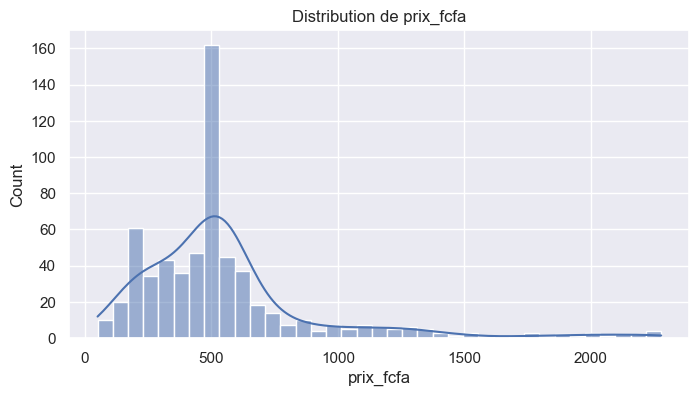

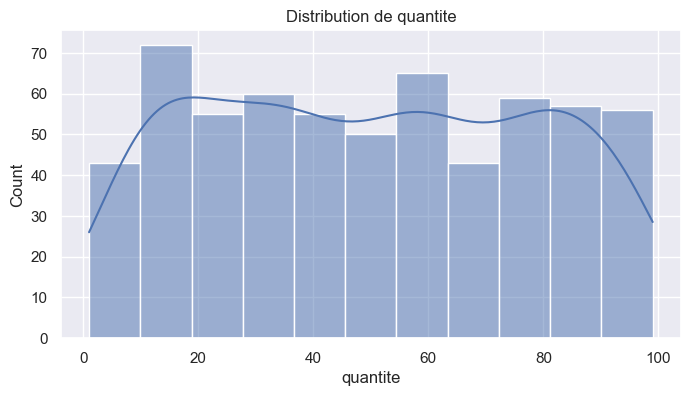

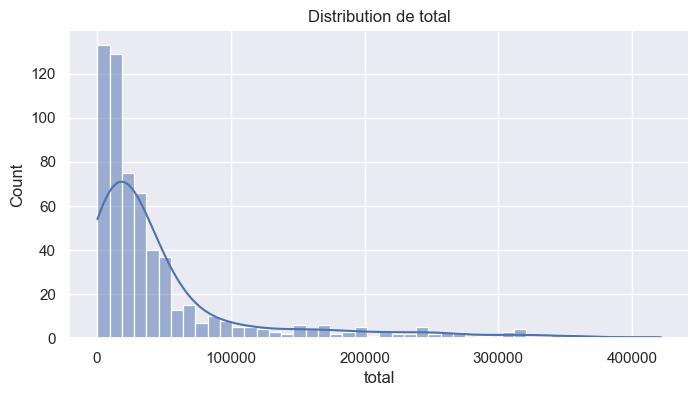

In [36]:
num_cols = ["prix_fcfa", "quantite", "total"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df_projet[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()

In [37]:
df_projet[num_cols].skew()

prix_fcfa    2.222070
quantite     0.041817
total        2.603673
dtype: float64

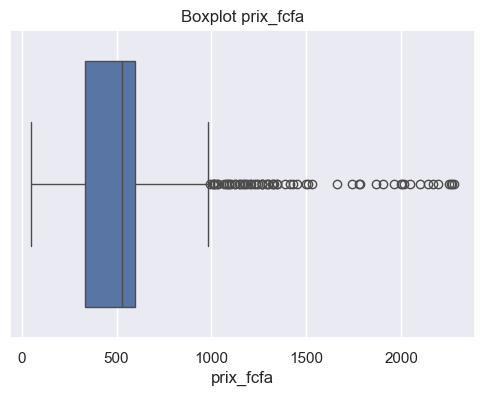

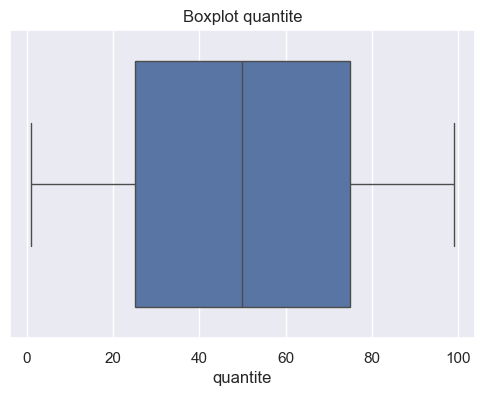

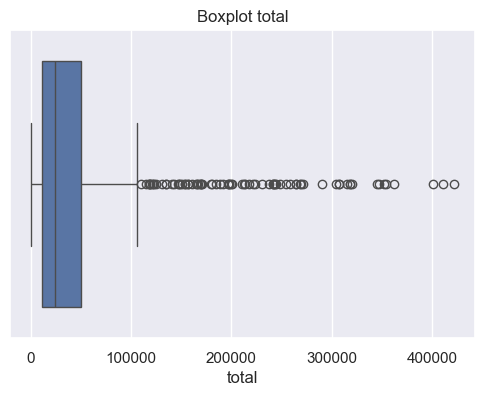

In [38]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_projet[col])
    plt.title(f"Boxplot {col}")
    plt.show()

In [41]:
df_projet[num_cols].corr()

,prix_fcfa,quantite,total
prix_fcfa,1.000000,-0.003344,0.233532
quantite,-0.003344,1.000000,0.449814
total,0.233532,0.449814,1.000000


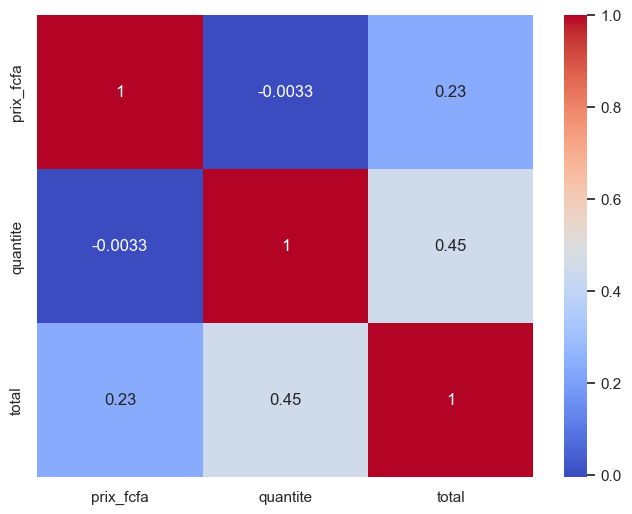

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(df_projet[num_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

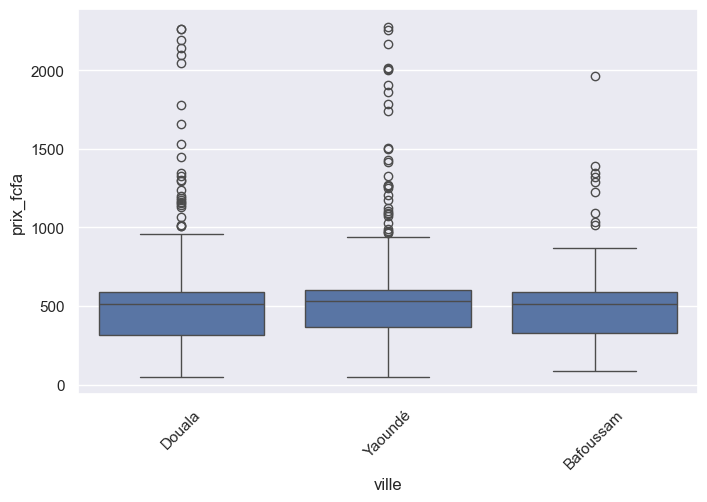

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_projet, x="ville", y="prix_fcfa")
plt.xticks(rotation=45)
plt.show()

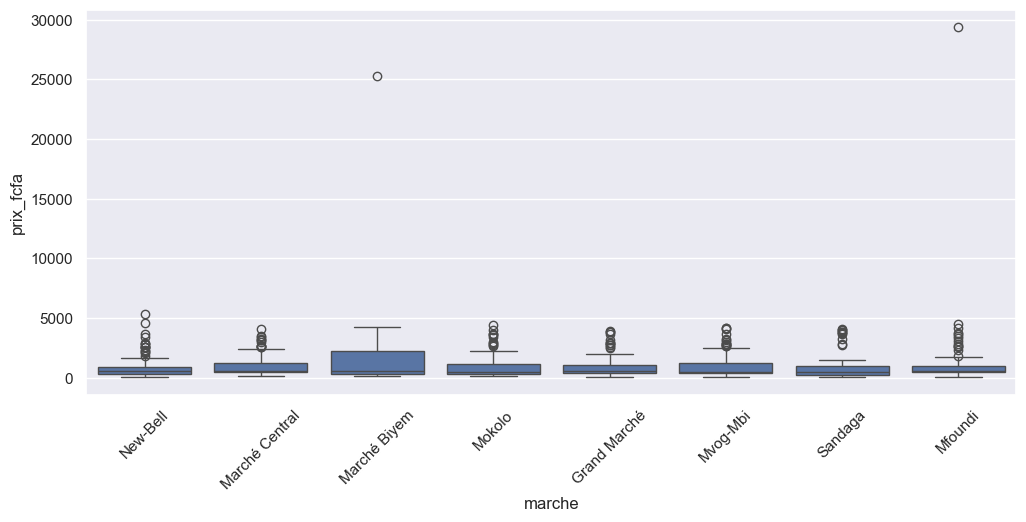

In [45]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x="marche", y="prix_fcfa")
plt.xticks(rotation=45)
plt.show()

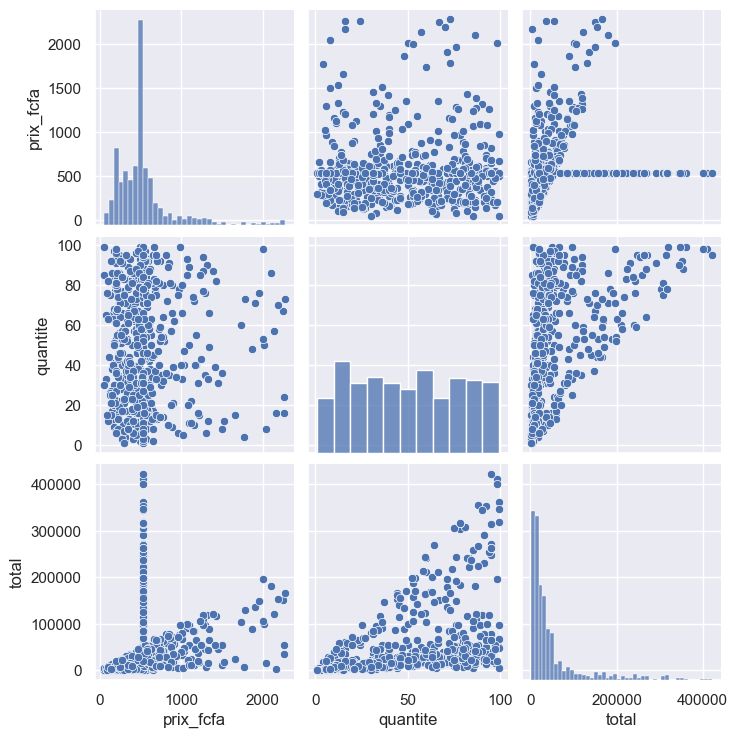

In [46]:
sns.pairplot(df_projet[num_cols])
plt.show()

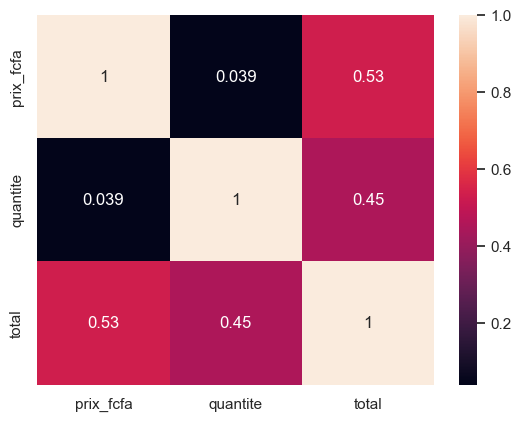

In [47]:
sns.heatmap(df[num_cols].corr(), annot=True)
plt.show()

In [48]:
df_projet["categorie_prix"] = pd.cut(
    df_projet["prix_fcfa"],
    bins=[0,500,1500,5000],
    labels=["Bas","Moyen","Élevé"]
)
print(df_projet["categorie_prix"])

0        Bas
1      Moyen
2        Bas
3      Moyen
4      Moyen
       ...  
610      Bas
611    Moyen
612      Bas
613      Bas
614      Bas
Name: categorie_prix, Length: 615, dtype: category
Categories (3, object): ['Bas' < 'Moyen' < 'Élevé']


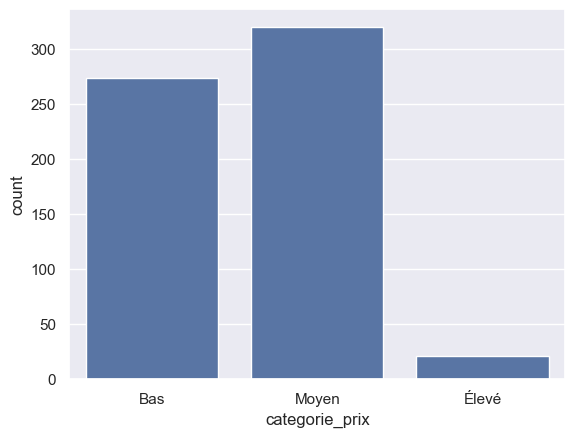

In [50]:
sns.countplot(data=df_projet, x="categorie_prix")
plt.show()

In [51]:
df_projet["prix_par_quantite"] = df_projet["total"] / df_projet["quantite"]

In [52]:
"T : trimestre "
mapping = {
    "Jan":"T1","Fév":"T1","Mar":"T1",
    "Avr":"T2","Mai":"T2","Jun":"T2"
}
df_projet["trimestre"] = df_projet["mois"].map(mapping)
print(df_projet["trimestre"])

0      T2
1      T2
2      T1
3      T1
4      T2
       ..
610    T2
611    T1
612    T1
613    T1
614    T2
Name: trimestre, Length: 615, dtype: object


In [53]:
df_projet["gamme"] = pd.cut(
    df_projet["prix_fcfa"],
    bins=[0,500,2000,10000],
    labels=["Low","Medium","High"]
)

In [54]:
from scipy.stats import f_oneway

douala = df_projet[df_projet["ville"]=="Douala"]["prix_fcfa"]
yaounde = df_projet[df_projet["ville"]=="Yaoundé"]["prix_fcfa"]
baf = df_projet[df_projet["ville"]=="Bafoussam"]["prix_fcfa"]

f_stat, p = f_oneway(douala, yaounde, baf)
print(f_stat, p)

0.06342368573331383 0.9385519090549855
